In [3]:
!pip install -q textblob nltk scikit-learn pandas matplotlib seaborn transformers torch --quiet

import nltk
nltk.download('vader_lexicon')
from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel

import re
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Using device: cpu


In [4]:
TICKER = "AAPL"

TWEETS_CSV_PATH = "stock_tweets.csv"
PRICES_CSV_PATH = "stock_yfinance_data.csv"

# threshold labeling
UP_THRESHOLD = 0.5       # >= +0.5% = UP
DOWN_THRESHOLD = -0.5    # <= -0.5% = DOWN

BATCH_SIZE = 16
FINBERT_EPOCHS = 2
LSTM_EPOCHS = 4
CNN_EPOCHS = 4
BAYESIAN_CNN_EPOCHS = 3

LR_FINBERT = 2e-5        # FinBERT
LR_DL = 1e-3             # LSTM/CNN
LR_SGLD = 1e-5           # SGLD step size for Bayesian CNN

label2id = {-1: 0, 0: 1, 1: 2}
id2label = {v: k for k, v in label2id.items()}

In [6]:
#loading csv
tweets_df = pd.read_csv(TWEETS_CSV_PATH)
prices_df = pd.read_csv(PRICES_CSV_PATH)

print("Tweets shape:", tweets_df.shape)
print("Prices shape:", prices_df.shape)
print("Tweets columns:", tweets_df.columns.tolist())
print("Prices columns:", prices_df.columns.tolist())

Tweets shape: (80793, 4)
Prices shape: (6300, 8)
Tweets columns: ['Date', 'Tweet', 'Stock Name', 'Company Name']
Prices columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Stock Name']


In [7]:
#data exploration
tweets_df["Date"] = pd.to_datetime(tweets_df["Date"], errors="coerce")
prices_df["Date"] = pd.to_datetime(prices_df["Date"], errors="coerce")

tweets_df = tweets_df.dropna(subset=["Date"])
prices_df = prices_df.dropna(subset=["Date"])

# filter for chosen ticker
tweets_df = tweets_df[tweets_df["Stock Name"] == TICKER].copy()
prices_df = prices_df[prices_df["Stock Name"] == TICKER].copy()

tweets_df["date"] = tweets_df["Date"].dt.date
prices_df["date"] = prices_df["Date"].dt.date

tweets_df["Tweet"] = tweets_df["Tweet"].astype(str)

print(f"\nFiltered for ticker: {TICKER}")
print("Tweets:", tweets_df.shape)
print("Prices:", prices_df.shape)

print("\nSample tweets:")
print(tweets_df[["Date", "Tweet"]].head())
print("\nSample prices:")
print(prices_df[["Date", "Open", "High", "Low", "Close", "Volume"]].head())


Filtered for ticker: AAPL
Tweets: (5056, 5)
Prices: (252, 9)

Sample tweets:
                           Date  \
55958 2022-09-29 22:23:54+00:00   
55959 2022-09-29 20:37:01+00:00   
55960 2022-09-29 20:19:43+00:00   
55961 2022-09-29 20:13:48+00:00   
55962 2022-09-29 19:50:00+00:00   

                                                   Tweet  
55958  $NIO just because I'm down money doesn't mean ...  
55959  After trading for 9+ years \n\nThis is how to ...  
55960  Not something you see very often.  \n-2 ATR mo...  
55961  $AAPL was down almost 5% today. Rare to see it...  
55962  $AAPL APPLE JUST FIRED ITS HEAD OF PROCUREMENT...  

Sample prices:
           Date        Open        High         Low       Close    Volume
1764 2021-09-30  143.660004  144.380005  141.279999  141.500000  89056700
1765 2021-10-01  141.899994  142.919998  139.110001  142.649994  94639600
1766 2021-10-04  141.759995  142.210007  138.270004  139.139999  98322000
1767 2021-10-05  139.490005  142.240005  139.

In [8]:
#NEXT-DAY RETURNSwhich are UP, DOWN, NEUTRAL
prices_df = prices_df.sort_values("Date").reset_index(drop=True)
prices_df["next_close"] = prices_df["Close"].shift(-1)
prices_df["return_pct"] = (prices_df["next_close"] - prices_df["Close"]) / prices_df["Close"] * 100.0

def label_from_return(r):
    if pd.isna(r):
        return np.nan
    if r >= UP_THRESHOLD:
        return 1
    elif r <= DOWN_THRESHOLD:
        return -1
    else:
        return 0

prices_df["label"] = prices_df["return_pct"].apply(label_from_return)
prices_labeled = prices_df.dropna(subset=["label"]).copy()
prices_labeled["label"] = prices_labeled["label"].astype(int)


prices_labeled["volatility_pct"] = (prices_labeled["High"] - prices_labeled["Low"]) / prices_labeled["Open"] * 100.0

print("\nPrices with labels & market indicators:")
print(prices_labeled[["Date", "Close", "Volume", "volatility_pct", "return_pct", "label"]].head())



Prices with labels & market indicators:
        Date       Close    Volume  volatility_pct  return_pct  label
0 2021-09-30  141.500000  89056700        2.157877    0.812717      1
1 2021-10-01  142.649994  94639600        2.684988   -2.460564     -1
2 2021-10-04  139.139999  98322000        2.779347    1.415841      1
3 2021-10-05  141.110001  80861100        2.064668    0.630713      1
4 2021-10-06  142.000000  83221100        2.710259    0.908446      1


In [9]:
#sentiment features
#vader and textblob
sia = SentimentIntensityAnalyzer()

tweets_df["vader_compound"] = tweets_df["Tweet"].apply(lambda x: sia.polarity_scores(x)["compound"])
tweets_df["textblob_polarity"] = tweets_df["Tweet"].apply(lambda x: TextBlob(x).sentiment.polarity)

print("\nTweets with sentiment:")
print(tweets_df[["Date", "Tweet", "vader_compound", "textblob_polarity"]].head())


Tweets with sentiment:
                           Date  \
55958 2022-09-29 22:23:54+00:00   
55959 2022-09-29 20:37:01+00:00   
55960 2022-09-29 20:19:43+00:00   
55961 2022-09-29 20:13:48+00:00   
55962 2022-09-29 19:50:00+00:00   

                                                   Tweet  vader_compound  \
55958  $NIO just because I'm down money doesn't mean ...          0.2500   
55959  After trading for 9+ years \n\nThis is how to ...          0.3612   
55960  Not something you see very often.  \n-2 ATR mo...          0.0000   
55961  $AAPL was down almost 5% today. Rare to see it...         -0.2500   
55962  $AAPL APPLE JUST FIRED ITS HEAD OF PROCUREMENT...         -0.6523   

       textblob_polarity  
55958           0.051962  
55959           0.000000  
55960           0.200000  
55961          -0.113889  
55962          -0.500000  


In [10]:
#aggregation using sentiment
daily_sent = (
    tweets_df
    .groupby("date")[["vader_compound", "textblob_polarity"]]
    .mean()
    .reset_index()
)

daily_merged = pd.merge(
    daily_sent,
    prices_labeled[["date", "Close", "Volume", "volatility_pct", "label"]],
    on="date",
    how="inner"
)

daily_merged = daily_merged.dropna(subset=["vader_compound", "textblob_polarity", "label"])
daily_merged = daily_merged.sort_values("date").reset_index(drop=True)

print("\nDaily merged data (sentiment + market indicators):")
print(daily_merged.head())
print("\nLabel distribution (daily):")
print(daily_merged["label"].value_counts())


Daily merged data (sentiment + market indicators):
         date  vader_compound  textblob_polarity       Close    Volume  \
0  2021-09-30        0.098900          -0.042030  141.500000  89056700   
1  2021-10-01        0.291891           0.193043  142.649994  94639600   
2  2021-10-04        0.047410           0.061264  139.139999  98322000   
3  2021-10-05        0.139060           0.116667  141.110001  80861100   
4  2021-10-06        0.190330           0.167485  142.000000  83221100   

   volatility_pct  label  
0        2.157877      1  
1        2.684988     -1  
2        2.779347      1  
3        2.064668      1  
4        2.710259      1  

Label distribution (daily):
label
 1    98
-1    91
 0    62
Name: count, dtype: int64



Daily samples: train=200, test=51

 Logistic Regression
Accuracy: 0.3333333333333333
Directional Accuracy: 0.3333333333333333
Macro F1: 0.16666666666666666
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00        22
           0       0.00      0.00      0.00        12
           1       0.33      1.00      0.50        17

    accuracy                           0.33        51
   macro avg       0.11      0.33      0.17        51
weighted avg       0.11      0.33      0.17        51



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: 

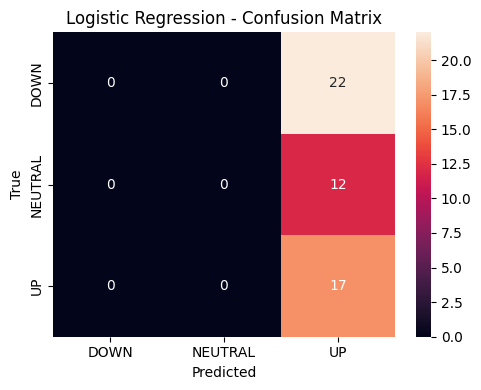

In [11]:
#logistic regression
def directional_accuracy(y_true, y_pred):

    return np.mean(y_true == y_pred)

X_daily = daily_merged[["vader_compound", "textblob_polarity", "Close", "Volume", "volatility_pct"]].values
y_daily = daily_merged["label"].values

n_daily = len(daily_merged)
train_size_daily = int(0.8 * n_daily)

X_train_d, X_test_d = X_daily[:train_size_daily], X_daily[train_size_daily:]
y_train_d, y_test_d = y_daily[:train_size_daily], y_daily[train_size_daily:]

print(f"\nDaily samples: train={len(X_train_d)}, test={len(X_test_d)}")

log_reg = LogisticRegression(max_iter=2000, multi_class="multinomial")
log_reg.fit(X_train_d, y_train_d)
y_pred_lr = log_reg.predict(X_test_d)

print("\n Logistic Regression")
print("Accuracy:", accuracy_score(y_test_d, y_pred_lr))
print("Directional Accuracy:", directional_accuracy(y_test_d, y_pred_lr))
print("Macro F1:", f1_score(y_test_d, y_pred_lr, average="macro"))
print(classification_report(y_test_d, y_pred_lr))

cm_lr = confusion_matrix(y_test_d, y_pred_lr, labels=[-1,0,1])
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt="d",
            xticklabels=["DOWN","NEUTRAL","UP"],
            yticklabels=["DOWN","NEUTRAL","UP"])
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()



 Random Forest (Daily Features)
Accuracy: 0.27450980392156865
Directional Accuracy: 0.27450980392156865
Macro F1: 0.2597384935206233
              precision    recall  f1-score   support

          -1       0.33      0.32      0.33        22
           0       0.22      0.17      0.19        12
           1       0.24      0.29      0.26        17

    accuracy                           0.27        51
   macro avg       0.26      0.26      0.26        51
weighted avg       0.28      0.27      0.27        51



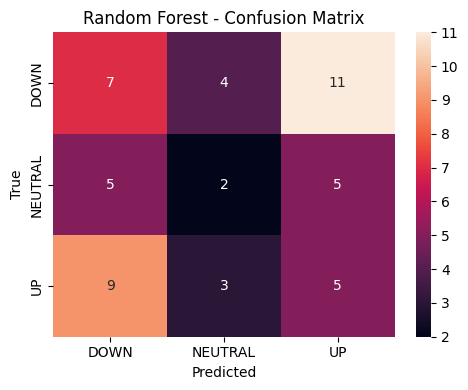

In [12]:
#random forest
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_SEED,
    class_weight="balanced_subsample"
)
rf.fit(X_train_d, y_train_d)
y_pred_rf = rf.predict(X_test_d)

print("\n Random Forest (Daily Features)")
print("Accuracy:", accuracy_score(y_test_d, y_pred_rf))
print("Directional Accuracy:", directional_accuracy(y_test_d, y_pred_rf))
print("Macro F1:", f1_score(y_test_d, y_pred_rf, average="macro"))
print(classification_report(y_test_d, y_pred_rf))

cm_rf = confusion_matrix(y_test_d, y_pred_rf, labels=[-1,0,1])
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d",
            xticklabels=["DOWN","NEUTRAL","UP"],
            yticklabels=["DOWN","NEUTRAL","UP"])
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


 SVM 
Accuracy: 0.3333333333333333
Directional Accuracy: 0.3333333333333333
Macro F1: 0.16666666666666666
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00        22
           0       0.00      0.00      0.00        12
           1       0.33      1.00      0.50        17

    accuracy                           0.33        51
   macro avg       0.11      0.33      0.17        51
weighted avg       0.11      0.33      0.17        51



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


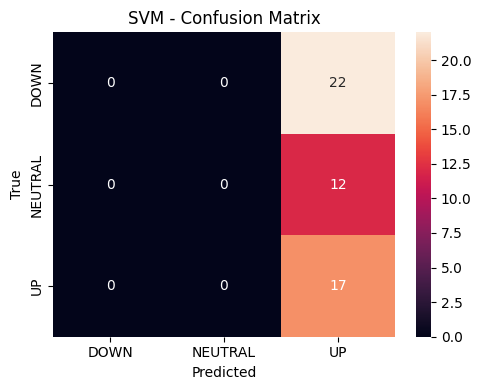

In [14]:
#SVM
svm_clf = SVC(kernel="rbf", C=1.0, gamma="scale")
svm_clf.fit(X_train_d, y_train_d)
y_pred_svm = svm_clf.predict(X_test_d)

print("\n SVM ")
print("Accuracy:", accuracy_score(y_test_d, y_pred_svm))
print("Directional Accuracy:", directional_accuracy(y_test_d, y_pred_svm))
print("Macro F1:", f1_score(y_test_d, y_pred_svm, average="macro"))
print(classification_report(y_test_d, y_pred_svm))

cm_svm = confusion_matrix(y_test_d, y_pred_svm, labels=[-1,0,1])
plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt="d",
            xticklabels=["DOWN","NEUTRAL","UP"],
            yticklabels=["DOWN","NEUTRAL","UP"])
plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [ ]:
#FOR DEEP MODELS
tweet_labeled = pd.merge(
    tweets_df[["Date", "date", "Tweet"]],
    prices_labeled[["date", "label"]],
    on="date",
    how="inner"
).dropna(subset=["label"])

tweet_labeled["label"] = tweet_labeled["label"].astype(int)
tweet_labeled = tweet_labeled.sort_values("Date").reset_index(drop=True)

print("\nTweet-level labeled data:")
print(tweet_labeled.head())
print("Tweet label distribution:", tweet_labeled["label"].value_counts())

# For NN: [-1,0,1] → [0,1,2]
tweet_labeled["label_id"] = tweet_labeled["label"].map(label2id)

texts = tweet_labeled["Tweet"].tolist()
labels_nn = tweet_labeled["label_id"].values

n_tweets = len(tweet_labeled)
train_size_t = int(0.8 * n_tweets)

train_texts = texts[:train_size_t]
train_labels = labels_nn[:train_size_t]
test_texts = texts[train_size_t:]
test_labels = labels_nn[train_size_t:]

print(f"\nTweet samples: train={len(train_texts)}, test={len(test_texts)}")


Tweet-level labeled data:
                       Date        date  \
0 2021-09-30 10:19:31+00:00  2021-09-30   
1 2021-09-30 10:22:53+00:00  2021-09-30   
2 2021-09-30 13:36:10+00:00  2021-09-30   
3 2021-09-30 15:30:03+00:00  2021-09-30   
4 2021-09-30 15:37:52+00:00  2021-09-30   

                                               Tweet  label  
0  I bought my first $AAPL stock in 2010. \n\nSin...      1  
1  The media is really pushing hard for their big...      1  
2  In 2020, Tim Cook, CEO of $AAPL, earned $265,0...      1  
3  This thread is just a broad overview of the ba...      1  
4  All about this trendline now on $AAPL, continu...      1  
Tweet label distribution: label
-1    1630
 1    1608
 0     861
Name: count, dtype: int64

Tweet samples: train=3279, test=820



 FINBERT MODEL
[FinBERT] Epoch 1/2 - Loss: 1.0747 - Acc: 0.4451 - F1: 0.2719
[FinBERT] Epoch 2/2 - Loss: 1.0466 - Acc: 0.3512 - F1: 0.2612

 FinBERT Test Report
              precision    recall  f1-score   support

        DOWN       0.47      0.30      0.36       388
     NEUTRAL       0.00      0.00      0.00       180
          UP       0.30      0.69      0.42       252

    accuracy                           0.35       820
   macro avg       0.26      0.33      0.26       820
weighted avg       0.31      0.35      0.30       820



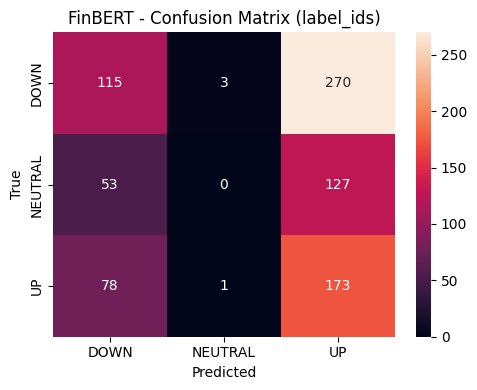

In [ ]:
#Finbert
print("\n FINBERT MODEL")

finbert_name = "ProsusAI/finbert"
tokenizer_fin = AutoTokenizer.from_pretrained(finbert_name)
base_model_fin = AutoModel.from_pretrained(finbert_name)

class FinBertClassifier(nn.Module):
    def __init__(self, base_model, num_classes=3):
        super().__init__()
        self.base_model = base_model
        hidden_size = base_model.config.hidden_size
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.base_model(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb = outputs.last_hidden_state[:, 0, :]
        x = self.dropout(cls_emb)
        logits = self.classifier(x)
        return logits

class FinBertTweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        enc = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long)
        }

train_ds_fin = FinBertTweetDataset(train_texts, train_labels, tokenizer_fin)
test_ds_fin = FinBertTweetDataset(test_texts, test_labels, tokenizer_fin)

train_loader_fin = DataLoader(train_ds_fin, batch_size=BATCH_SIZE, shuffle=True)
test_loader_fin = DataLoader(test_ds_fin, batch_size=BATCH_SIZE, shuffle=False)

finbert_model = FinBertClassifier(base_model_fin, num_classes=3).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(finbert_model.parameters(), lr=LR_FINBERT)

def train_epoch_fin(model, dataloader):
    model.train()
    total_loss = 0
    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels_b = batch["label"].to(device)
        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def eval_fin(model, dataloader):
    model.eval()
    preds, gold = [], []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels_b = batch["label"].to(device)
            logits = model(input_ids, attention_mask)
            pred = torch.argmax(logits, dim=1)
            preds.extend(pred.cpu().numpy().tolist())
            gold.extend(labels_b.cpu().numpy().tolist())
    return np.array(gold), np.array(preds)

for epoch in range(1, FINBERT_EPOCHS + 1):
    train_loss = train_epoch_fin(finbert_model, train_loader_fin)
    y_true_fin, y_pred_fin = eval_fin(finbert_model, test_loader_fin)
    acc = accuracy_score(y_true_fin, y_pred_fin)
    f1 = f1_score(y_true_fin, y_pred_fin, average="macro")
    print(f"[FinBERT] Epoch {epoch}/{FINBERT_EPOCHS} - Loss: {train_loss:.4f} - Acc: {acc:.4f} - F1: {f1:.4f}")

print("\n FinBERT Test Report")
print(classification_report(y_true_fin, y_pred_fin, target_names=["DOWN","NEUTRAL","UP"]))

cm_fin = confusion_matrix(y_true_fin, y_pred_fin, labels=[0,1,2])
plt.figure(figsize=(5,4))
sns.heatmap(cm_fin, annot=True, fmt="d",
            xticklabels=["DOWN","NEUTRAL","UP"],
            yticklabels=["DOWN","NEUTRAL","UP"])
plt.title("FinBERT - Confusion Matrix (label_ids)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [ ]:
#tokenization for LSTM and CNN

def simple_tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    tokens = text.split()
    return tokens

all_tokens = []
for t in train_texts:
    all_tokens.extend(simple_tokenize(t))

counter = Counter(all_tokens)
vocab_size = 20000
most_common = counter.most_common(vocab_size - 2)

word2id = {"<PAD>": 0, "<UNK>": 1}
for i, (w, _) in enumerate(most_common, start=2):
    word2id[w] = i

def encode_text(text, max_len=40):
    tokens = simple_tokenize(text)
    ids = [word2id.get(tok, 1) for tok in tokens]
    if len(ids) < max_len:
        ids += [0] * (max_len - len(ids))
    else:
        ids = ids[:max_len]
    return ids

max_seq_len = 40

class SimpleTextDataset(Dataset):
    def __init__(self, texts, labels, max_len=40):
        self.texts = texts
        self.labels = labels
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x_ids = encode_text(self.texts[idx], self.max_len)
        y = int(self.labels[idx])
        return torch.tensor(x_ids, dtype=torch.long), torch.tensor(y, dtype=torch.long)

train_ds_dl = SimpleTextDataset(train_texts, train_labels, max_len=max_seq_len)
test_ds_dl = SimpleTextDataset(test_texts, test_labels, max_len=max_seq_len)

train_loader_dl = DataLoader(train_ds_dl, batch_size=BATCH_SIZE, shuffle=True)
test_loader_dl = DataLoader(test_ds_dl, batch_size=BATCH_SIZE, shuffle=False)

vocab_len = len(word2id)

def train_epoch_generic(model, dataloader, optimizer, criterion):
    model.train()
    total_loss = 0
    for xb, yb in dataloader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def eval_generic(model, dataloader):
    model.eval()
    preds, gold = [], []
    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1)
            preds.extend(pred.cpu().numpy().tolist())
            gold.extend(yb.cpu().numpy().tolist())
    return np.array(gold), np.array(preds)



 LSTM MODEL
[LSTM] Epoch 1/4 - Loss: 1.0685 - Acc: 0.3305 - F1: 0.2220
[LSTM] Epoch 2/4 - Loss: 1.0352 - Acc: 0.3280 - F1: 0.2230
[LSTM] Epoch 3/4 - Loss: 0.9843 - Acc: 0.3463 - F1: 0.2652
[LSTM] Epoch 4/4 - Loss: 0.8847 - Acc: 0.3341 - F1: 0.2568

 LSTM Test Report 
              precision    recall  f1-score   support

        DOWN       0.48      0.15      0.23       388
     NEUTRAL       0.36      0.06      0.10       180
          UP       0.31      0.82      0.45       252

    accuracy                           0.33       820
   macro avg       0.38      0.34      0.26       820
weighted avg       0.40      0.33      0.27       820



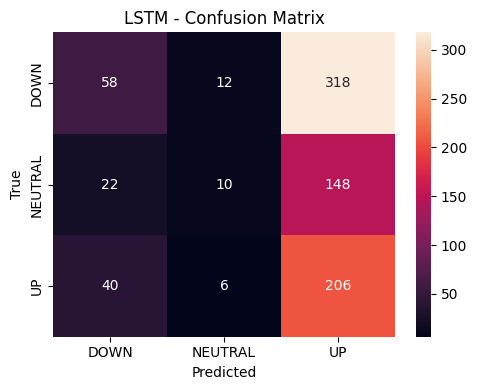

In [ ]:
#LSTM
print("\n LSTM MODEL")

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_classes=3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        out, (h_n, c_n) = self.lstm(emb)
        last_hidden = h_n[-1]
        x = self.dropout(last_hidden)
        logits = self.fc(x)
        return logits

lstm_model = LSTMClassifier(vocab_len).to(device)
criterion_lstm = nn.CrossEntropyLoss()
optimizer_lstm = torch.optim.Adam(lstm_model.parameters(), lr=LR_DL)

for epoch in range(1, LSTM_EPOCHS + 1):
    loss = train_epoch_generic(lstm_model, train_loader_dl, optimizer_lstm, criterion_lstm)
    y_true_lstm, y_pred_lstm = eval_generic(lstm_model, test_loader_dl)
    acc = accuracy_score(y_true_lstm, y_pred_lstm)
    f1 = f1_score(y_true_lstm, y_pred_lstm, average="macro")
    print(f"[LSTM] Epoch {epoch}/{LSTM_EPOCHS} - Loss: {loss:.4f} - Acc: {acc:.4f} - F1: {f1:.4f}")

print("\n LSTM Test Report ")
print(classification_report(y_true_lstm, y_pred_lstm,
                            target_names=["DOWN","NEUTRAL","UP"]))

cm_lstm = confusion_matrix(y_true_lstm, y_pred_lstm, labels=[0,1,2])
plt.figure(figsize=(5,4))
sns.heatmap(cm_lstm, annot=True, fmt="d",
            xticklabels=["DOWN","NEUTRAL","UP"],
            yticklabels=["DOWN","NEUTRAL","UP"])
plt.title("LSTM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

[CNN] Epoch 1/4 - Loss: 1.1525 - Acc: 0.3085 - F1: 0.1673
[CNN] Epoch 2/4 - Loss: 0.9154 - Acc: 0.3890 - F1: 0.2979
[CNN] Epoch 3/4 - Loss: 0.7748 - Acc: 0.3549 - F1: 0.3173
[CNN] Epoch 4/4 - Loss: 0.5592 - Acc: 0.4427 - F1: 0.2912

 CNN Test Report
              precision    recall  f1-score   support

        DOWN       0.47      0.78      0.59       388
     NEUTRAL       0.25      0.01      0.01       180
          UP       0.34      0.23      0.27       252

    accuracy                           0.44       820
   macro avg       0.35      0.34      0.29       820
weighted avg       0.38      0.44      0.37       820



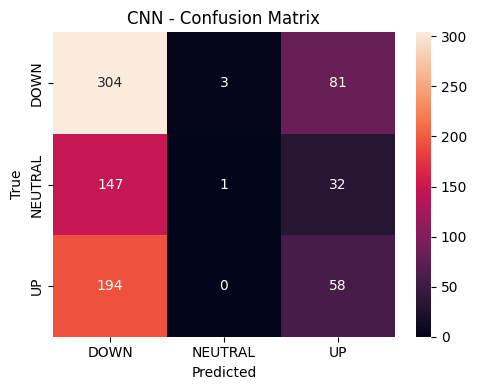

In [ ]:
#CNN

class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_classes=3, kernel_sizes=[3,4,5], num_filters=100, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=k)
            for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        emb = self.embedding(x)            # (B,L,E)
        emb = emb.permute(0, 2, 1)         # (B,E,L)
        conv_outs = []
        for conv in self.convs:
            c = torch.relu(conv(emb))      # (B,F,L')
            pooled = torch.max(c, dim=2)[0]
            conv_outs.append(pooled)       # (B,F)
        x = torch.cat(conv_outs, dim=1)    # (B,F*len(k))
        x = self.dropout(x)
        logits = self.fc(x)
        return logits

cnn_model = TextCNN(vocab_len).to(device)
criterion_cnn = nn.CrossEntropyLoss()
optimizer_cnn = torch.optim.Adam(cnn_model.parameters(), lr=LR_DL)

for epoch in range(1, CNN_EPOCHS + 1):
    loss = train_epoch_generic(cnn_model, train_loader_dl, optimizer_cnn, criterion_cnn)
    y_true_cnn, y_pred_cnn = eval_generic(cnn_model, test_loader_dl)
    acc = accuracy_score(y_true_cnn, y_pred_cnn)
    f1 = f1_score(y_true_cnn, y_pred_cnn, average="macro")
    print(f"[CNN] Epoch {epoch}/{CNN_EPOCHS} - Loss: {loss:.4f} - Acc: {acc:.4f} - F1: {f1:.4f}")

print("\n CNN Test Report")
print(classification_report(y_true_cnn, y_pred_cnn,
                            target_names=["DOWN","NEUTRAL","UP"]))

cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn, labels=[0,1,2])
plt.figure(figsize=(5,4))
sns.heatmap(cm_cnn, annot=True, fmt="d",
            xticklabels=["DOWN","NEUTRAL","UP"],
            yticklabels=["DOWN","NEUTRAL","UP"])
plt.title("CNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

[Bayesian CNN] Epoch 1/3 - Loss: 1.6994 - Acc: 0.3232 - F1: 0.2729
[Bayesian CNN] Epoch 2/3 - Loss: 2.8350 - Acc: 0.3232 - F1: 0.2961
[Bayesian CNN] Epoch 3/3 - Loss: 4.2504 - Acc: 0.3671 - F1: 0.2733

 Bayesian CNN 
              precision    recall  f1-score   support

        DOWN       0.52      0.27      0.35       388
     NEUTRAL       0.07      0.01      0.01       180
          UP       0.32      0.78      0.46       252

    accuracy                           0.37       820
   macro avg       0.31      0.35      0.27       820
weighted avg       0.36      0.37      0.31       820



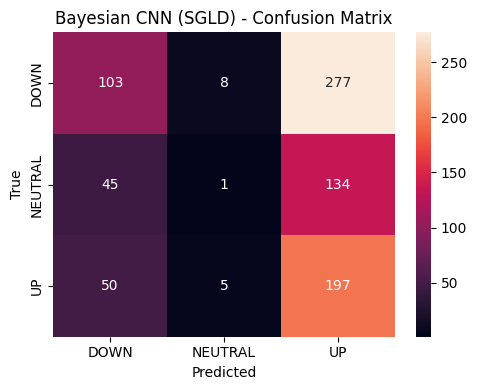


Average predictive uncertainty : 0.28268685936927795


In [ ]:
#BAYESIAN CNN with SGLD-style updates

class BayesianTextCNN(TextCNN):

    pass

bayes_cnn = BayesianTextCNN(vocab_len, dropout=0.5).to(device)
criterion_bayes = nn.CrossEntropyLoss()

def sgld_update(model, lr_sgld):
    with torch.no_grad():
        for param in model.parameters():
            if param.grad is None:
                continue
            noise = torch.randn_like(param.grad) * (lr_sgld ** 0.5)
            param.data += -0.5 * lr_sgld * param.grad + noise
            param.grad.zero_()

def train_epoch_sgld(model, dataloader, lr_sgld):
    model.train()
    total_loss = 0
    for xb, yb in dataloader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)
        loss = criterion_bayes(logits, yb)
        loss.backward()
        sgld_update(model, lr_sgld)
        total_loss += loss.item()
    return total_loss / len(dataloader)

def eval_bayesian_mc(model, dataloader, mc_samples=20):

    model.train()
    all_probs = []
    gold = None

    with torch.no_grad():
        for _ in range(mc_samples):
            preds_this = []
            gold_this = []
            for xb, yb in dataloader:
                xb = xb.to(device)
                yb = yb.to(device)
                logits = model(xb)
                probs = torch.softmax(logits, dim=1)
                preds_this.append(probs.cpu().numpy())
                gold_this.extend(yb.cpu().numpy().tolist())
            preds_this = np.concatenate(preds_this, axis=0)
            all_probs.append(preds_this)
            if gold is None:
                gold = np.array(gold_this)

    all_probs = np.stack(all_probs, axis=0)
    mean_probs = all_probs.mean(axis=0)
    std_probs = all_probs.std(axis=0)

    y_pred = mean_probs.argmax(axis=1)
    uncertainty = std_probs.mean(axis=1)

    return gold, y_pred, uncertainty

for epoch in range(1, BAYESIAN_CNN_EPOCHS + 1):
    loss = train_epoch_sgld(bayes_cnn, train_loader_dl, LR_SGLD)
    y_true_bc, y_pred_bc, unc_bc = eval_bayesian_mc(bayes_cnn, test_loader_dl, mc_samples=5)
    acc = accuracy_score(y_true_bc, y_pred_bc)
    f1 = f1_score(y_true_bc, y_pred_bc, average="macro")
    print(f"[Bayesian CNN] Epoch {epoch}/{BAYESIAN_CNN_EPOCHS} - Loss: {loss:.4f} - Acc: {acc:.4f} - F1: {f1:.4f}")

print("\n Bayesian CNN ")
print(classification_report(y_true_bc, y_pred_bc,
                            target_names=["DOWN","NEUTRAL","UP"]))

cm_bayes = confusion_matrix(y_true_bc, y_pred_bc, labels=[0,1,2])
plt.figure(figsize=(5,4))
sns.heatmap(cm_bayes, annot=True, fmt="d",
            xticklabels=["DOWN","NEUTRAL","UP"],
            yticklabels=["DOWN","NEUTRAL","UP"])
plt.title("Bayesian CNN (SGLD) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

print("\nAverage predictive uncertainty :", float(np.mean(unc_bc)))


Fetching data for AAPL...


[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-252785229.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  start_price = float(df["Close"].iloc[0])
/tmp/ipython-input-252785229.py:24: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  end_price = float(df["Close"].iloc[-1])


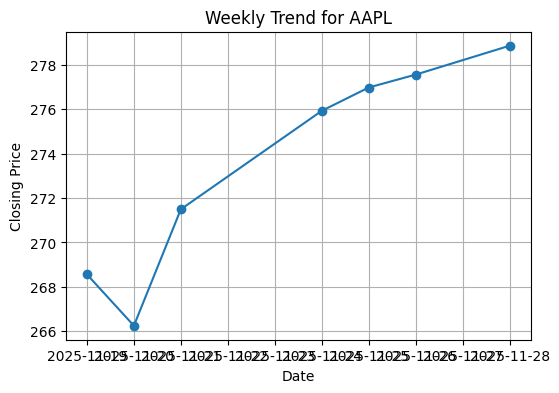


Fetching data for TSLA...


[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-252785229.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  start_price = float(df["Close"].iloc[0])
/tmp/ipython-input-252785229.py:24: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  end_price = float(df["Close"].iloc[-1])


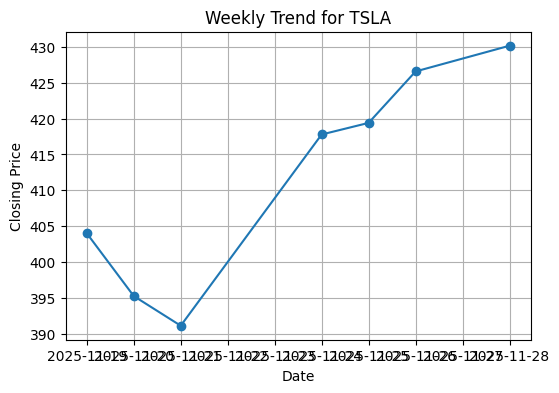


Fetching data for MSFT...


[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-252785229.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  start_price = float(df["Close"].iloc[0])
/tmp/ipython-input-252785229.py:24: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  end_price = float(df["Close"].iloc[-1])


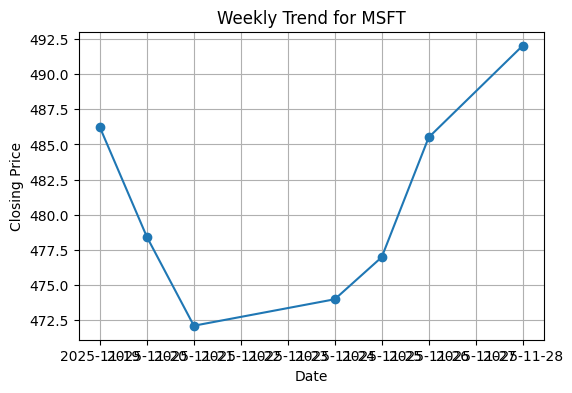


Fetching data for AMZN...


[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-252785229.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  start_price = float(df["Close"].iloc[0])
/tmp/ipython-input-252785229.py:24: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  end_price = float(df["Close"].iloc[-1])


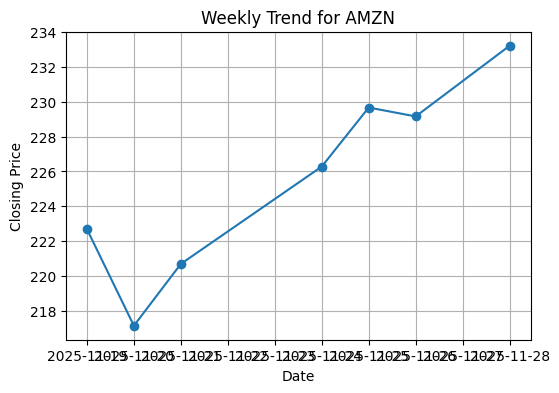


Fetching data for GOOG...


[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-252785229.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  start_price = float(df["Close"].iloc[0])
/tmp/ipython-input-252785229.py:24: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  end_price = float(df["Close"].iloc[-1])


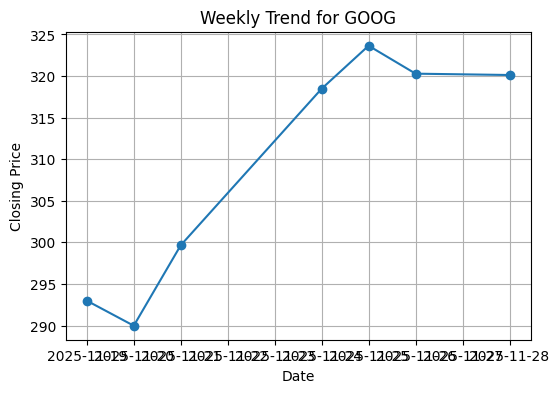


 Weekly Performance Summary (Last 7 Days) 
Symbol  Start_Price  End_Price  Change  Pct_Change
  GOOG       292.99     320.12   27.13        9.26
  TSLA       403.99     430.17   26.18        6.48
  AMZN       222.69     233.22   10.53        4.73
  AAPL       268.56     278.85   10.29        3.83
  MSFT       486.21     492.01    5.80        1.19

 Demo Recommendation 
BUY candidate: GOOG  →  9.26% this week
SELL/AVOID candidate: MSFT → 1.19% this week


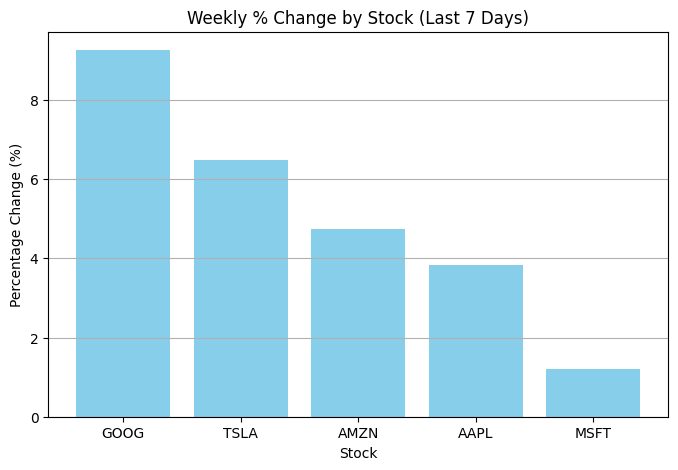

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

def analyze_stocks_for_week(symbols):
    results = []

    for symbol in symbols:
        print(f"\nFetching data for {symbol}...")
        data = yf.download(symbol, period="7d", auto_adjust=True)

        if data.empty:
            print(f"  No data for {symbol}, skipping.")
            continue

        df = data.reset_index()

        if "Close" not in df.columns:
            print(f"   No 'Close' column for {symbol}, skipping.")
            continue


        start_price = float(df["Close"].iloc[0])
        end_price = float(df["Close"].iloc[-1])
        change = end_price - start_price
        pct_change = (change / start_price) * 100

        results.append({
            "Symbol": symbol,
            "Start_Price": start_price,
            "End_Price": end_price,
            "Change": change,
            "Pct_Change": pct_change
        })

        # weekly trend for each stock
        plt.figure(figsize=(6,4))
        plt.plot(df["Date"], df["Close"], marker='o')
        plt.title(f"Weekly Trend for {symbol}")
        plt.xlabel("Date")
        plt.ylabel("Closing Price")
        plt.grid(True)
        plt.show()

    if not results:
        print("No valid data for any symbols.")
        return

    summary = pd.DataFrame(results)
    summary_sorted = summary.sort_values(by="Pct_Change", ascending=False).reset_index(drop=True)

    print("\n Weekly Performance Summary (Last 7 Days) ")
    print(summary_sorted.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

    # Best (BUY and worst (SELL for candidate)
    best = summary_sorted.iloc[0]
    worst = summary_sorted.iloc[-1]

    print("\n Demo Recommendation ")
    print(f"BUY candidate: {best['Symbol']}  →  {best['Pct_Change']:.2f}% this week")
    print(f"SELL/AVOID candidate: {worst['Symbol']} → {worst['Pct_Change']:.2f}% this week")

    # Bar chart
    plt.figure(figsize=(8, 5))
    plt.bar(summary_sorted["Symbol"], summary_sorted["Pct_Change"], color="skyblue")
    plt.title("Weekly % Change by Stock (Last 7 Days)")
    plt.xlabel("Stock")
    plt.ylabel("Percentage Change (%)")
    plt.grid(True, axis='y')
    plt.show()

    return summary_sorted


# 🔹 Example stocks to analyze
symbols = ["AAPL", "TSLA", "MSFT", "AMZN", "GOOG"]

summary = analyze_stocks_for_week(symbols)


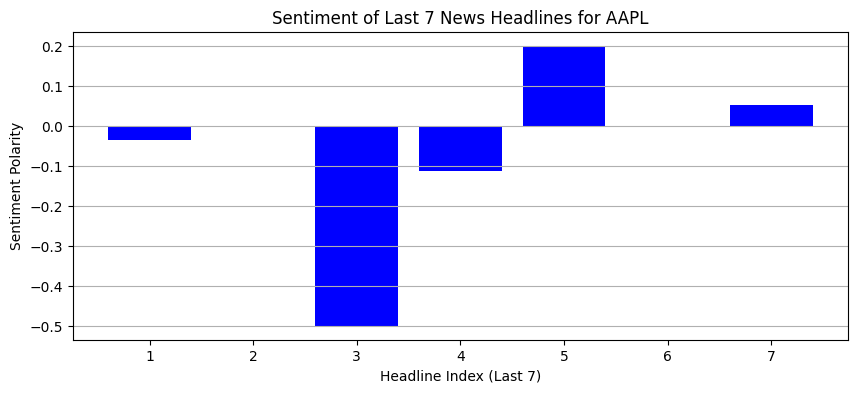

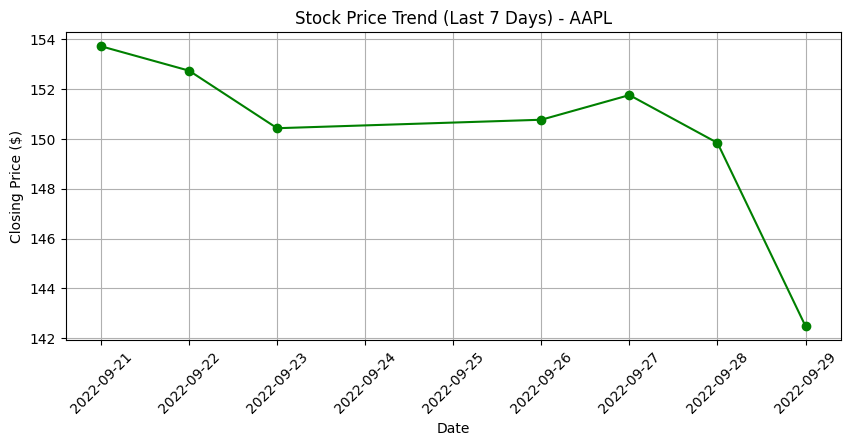

Symbol: AAPL
Average Sentiment (last 7 headlines): -0.057
Price Change (last 7 days): -7.31%
 Negative news sentiment + falling prices → SELL signal


In [ ]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np

#sentiment vs price

def sentiment_vs_movement(symbol):

    tweets = pd.read_csv("stock_tweets.csv")
    yf_data = pd.read_csv("stock_yfinance_data.csv")
    tweets = tweets[tweets["Stock Name"] == symbol].copy()
    yf_data = yf_data[yf_data["Stock Name"] == symbol].copy()
    tweets["Date"] = pd.to_datetime(tweets["Date"])
    yf_data["Date"] = pd.to_datetime(yf_data["Date"])
    tweets = tweets.sort_values("Date")
    yf_data = yf_data.sort_values("Date")
    latest_news = tweets.tail(7)
    headlines = latest_news["Tweet"].tolist()
    sentiments = [TextBlob(h).sentiment.polarity for h in headlines]
    last_7_days = yf_data.tail(7)
    prices = last_7_days["Close"].values

    if len(prices) < 7:
        print("Not enough price data available for", symbol)
        return

    # this is Sentiment Bar Plot
    plt.figure(figsize=(10,4))
    plt.bar(range(1,8), sentiments, color="blue")
    plt.title(f"Sentiment of Last 7 News Headlines for {symbol}")
    plt.xlabel("Headline Index (Last 7)")
    plt.ylabel("Sentiment Polarity")
    plt.grid(True, axis='y')
    plt.show()

    # this is Stock Price Line Plot
    plt.figure(figsize=(10,4))
    plt.plot(last_7_days["Date"], prices, marker='o', color="green")
    plt.title(f"Stock Price Trend (Last 7 Days) - {symbol}")
    plt.xlabel("Date")
    plt.ylabel("Closing Price ($)")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

    # Simple interpretation
    avg_sent = np.mean(sentiments)
    price_change = (prices[-1] - prices[0]) / prices[0] * 100


    print(f"Symbol: {symbol}")
    print(f"Average Sentiment (last 7 headlines): {avg_sent:.3f}")
    print(f"Price Change (last 7 days): {price_change:.2f}%")

    if avg_sent > 0 and price_change > 0:
        print(" Positive news sentiment + rising prices → BUY signal")
    elif avg_sent < 0 and price_change < 0:
        print(" Negative news sentiment + falling prices → SELL signal")
    else:
        print(" Mixed signals → HOLD / NEUTRAL")

# RUN THE DEMO
sentiment_vs_movement("AAPL")
